# 01 - Simulating a dataset using `waveforms`

This is a demonstration version of `simulating_data.ipynb` in the `notebooks` directory, which is working notebook for different dataset variations. 

In [1]:
import sys
sys.path.append('..')
sys.path.append('../..')

import random
import pickle
import importlib

import numpy as np
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import wandb

from data_utils import *
from waveforms.waveforms_module.make_waveform import BatchedLightSimulation

### First, instantiate a simulator (need to clone `waveforms`)

In [2]:
device = torch.device('cuda:0')
sim = BatchedLightSimulation(cfg="../../waveforms/templates/waveform_sim.yaml").to(device)

# Changing Resolution & Other Params
# Note: Delay distributions' time parameters are in units of microseconds
# Some other params relating to waveform length are in units of nanoseconds

params = dict()
params['light_tick_size'] = 0.001 # 100 picoseconds in microseconds units
params['downsample_factor'] = 10
params['tpb_tau'] = 0.002 # us
params['offset'] = 0 # ns
params['n_ticks'] = 80000 # ns

# Picking nominal values for all - MUST set these to be constant between datasets
params['light_gain'] = -45.0
params['light_oscillation_period'] = 0.11
params['light_response_time'] = 0.055
sim.reconfigure(params)

print(f"1 time tick = {sim.light_tick_size} microseconds.")
print(f"Downsample by factor of {sim.downsample_factor}.")
print(f"Offset flash by {sim.offset} ns from window start.")
print(f"Waveforms are {sim.n_ticks} ns long.")
print(f"Light gain is {sim.light_gain} ADC.")

BatchedLightSimulation Config:
	SINGLET_FRACTION: uniform(0.1, 0.5)
	LIGHT_OSCILLATION_PERIOD: uniform(0.05, 0.20)
	LIGHT_RESPONSE_TIME: uniform(0.01, 0.10)
	LIGHT_GAIN: uniform(-50.0, -20.0)
	TAU_S: uniform(0.0001, 0.01)
	TAU_T: uniform(0.9, 2.1)
	
	NOMINAL_SINGLET_FRACTION: 0.000000001 #0.35
	NOMINAL_LIGHT_OSCILLATION_PERIOD: 0.11     # us
	NOMINAL_LIGHT_RESPONSE_TIME: 0.055         # us^-1
	NOMINAL_TAU_S: 0.001                       # us
	NOMINAL_TAU_T: 1.530                       # us
	NOMINAL_LIGHT_GAIN: -45.0                  # ADC us/pe
	
	LIGHT_TICK_SIZE: 0.001                     # us
	LIGHT_WINDOW: [1, 10]
1 time tick = 0.001 microseconds.
Downsample by factor of 10.
Offset flash by 0 ns from window start.
Waveforms are 80000 ns long.
Light gain is Parameter containing:
tensor(1., device='cuda:0', requires_grad=True) ADC.


### Sanity Check: 1 Photon Waveform Shape
- Rising edge should be a few nanoseconds to peak

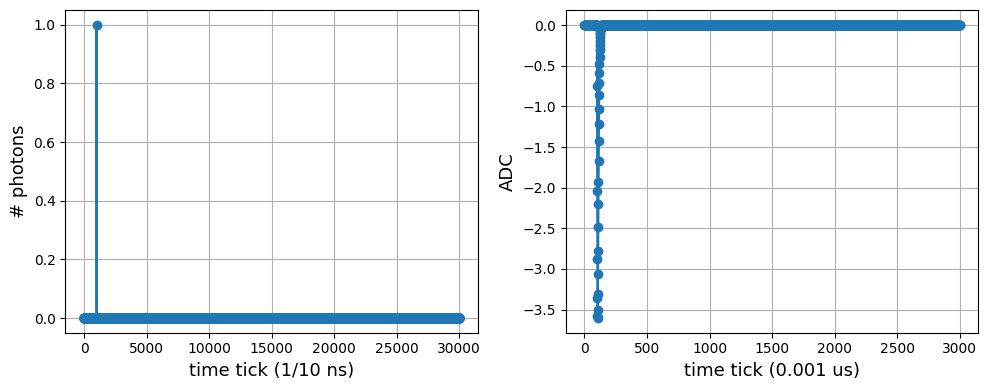

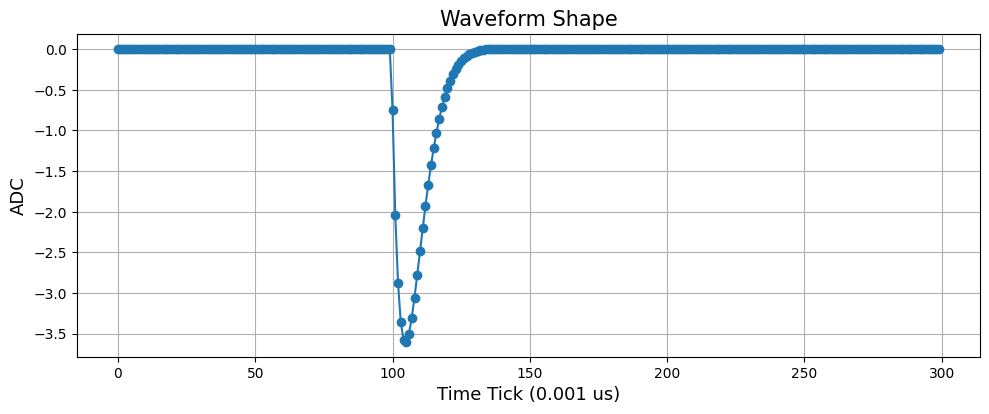

In [3]:
# Generating Waveform
nphotons = 1
pmt_ids = torch.zeros(nphotons, dtype=torch.int64)
arrival_times = torch.zeros(nphotons, dtype=torch.int64) + 1000 # pre-delay, arrive at 100 ns
wf = sim.gen_waveform(mode='precise', pmt_ids=pmt_ids, arrival_times=arrival_times, n_pmts=1)

# Electronics Convolution
output, _ = sim(wf.to(device), scintillation=False, tpb_delay=False, combined=False)
output = output.detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

# First plot
axes[0].plot(wf[0][:30000], marker = 'o')
axes[0].set_ylabel("# photons", fontsize=13)
axes[0].set_xlabel("time tick (1/10 ns)", fontsize=13)
axes[0].grid(True)
axes[1].plot(output[:3000], marker='o')
axes[1].grid(True)
axes[1].set_xlabel(f"time tick ({sim.light_tick_size} us)", fontsize=13)
axes[1].set_ylabel("ADC", fontsize=13)
plt.tight_layout()
plt.show()

# Second plot
plt.figure(figsize=(10, 4))
plt.plot(output[:300], marker='o')
plt.grid(True)
plt.xlabel(f"Time Tick ({sim.light_tick_size} us)", fontsize=13)
plt.ylabel("ADC", fontsize=13)
plt.tight_layout()
plt.title("Waveform Shape", fontsize=15)
plt.show()

In [4]:
single_phot_amplitude = output.min()
print(single_phot_amplitude)

-3.6047788


### Inspect Shapes of Waveforms w/ Different Amplitudes

1325.6410640489776


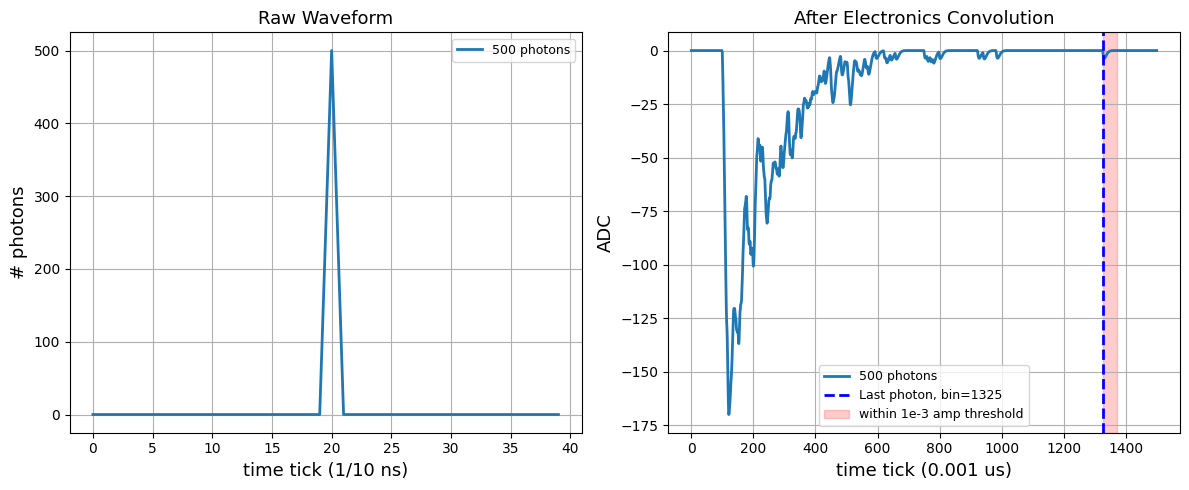

In [12]:
# nphotons_list = [1, 2, 5, 10, 15, 100, 200, 500]
nphotons_list = [500]
latest_photons = []

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for nphotons in nphotons_list:
    # Generate waveform
    pmt_ids = torch.zeros(nphotons, dtype=torch.int64)
    arrival_times = torch.zeros(nphotons, dtype=torch.int64) + 1000  # pre-delay, arrive at 100 ns
    wf = sim.gen_waveform(mode='precise', pmt_ids=pmt_ids, arrival_times=arrival_times, n_pmts=1)

    # Electronics convolution
    output, info = sim(wf.to(device), scintillation=False, tpb_delay=False, combined=True)

    # Calculate last photon arrival time
    info['scintillation_delays'] = np.array(info['scintillation_delays'])
    info['tpb_emission_delays'] = np.array(info['tpb_emission_delays'])
    full_delay = (info['scintillation_delays'] + info['tpb_emission_delays']) * (1000 / sim.downsample_factor)
    max_delay = max(full_delay)
    # max_scint = max(info['scintillation_delays']) * (1000 / sim.downsample_factor)  # convert to ns
    # max_tpb = max(info['tpb_emission_delays']) * (1000 / sim.downsample_factor)

    latest_photons.append(max_delay + (1000 // 10))
        
    output = output.detach().cpu().numpy()

    # Plot both waveforms
    axes[0].plot(wf[0][980:1020], label=f"{nphotons} photons", linewidth=2)
    axes[1].plot(output[0:1500], label=f"{nphotons} photons", linewidth=2)
# Formatting
axes[0].set_title("Raw Waveform", fontsize=13)
axes[0].set_ylabel("# photons", fontsize=13)
axes[0].set_xlabel("time tick (1/10 ns)", fontsize=13)
axes[0].grid(True)
axes[0].legend(fontsize=9)

# Mark latest photons
for j, elem in enumerate(np.sort(latest_photons)):
    print(elem)
    axes[1].axvline(
        x=elem,
        color="b",
        linestyle="--",
        linewidth=2,
        label=f"Last photon, bin={int(elem)}"
    )
    axes[1].axvspan(elem, elem+47, color='red', alpha=0.2, label='within 1e-3 amp threshold')
    
axes[1].set_title("After Electronics Convolution", fontsize=13)
axes[1].set_xlabel(f"time tick ({sim.light_tick_size} us)", fontsize=13)
axes[1].set_ylabel("ADC", fontsize=13)
axes[1].grid(True)
axes[1].legend()
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [96]:
# Using impulse from electronics response kernel to determine end of tail
m = sim
ticks = torch.arange(0, m.conv_ticks * 4, device=m.time_ticks.device)  # search range
t = ticks * m.light_tick_size
period = 10 ** (m.log_light_oscillation_period * m.nominal_log_light_oscillation_period)
tau    = 10 ** (m.log_light_response_time * m.nominal_log_light_response_time)

impulse = torch.exp(-t / tau) * torch.sin(t / period)
# apply same scaling used in sipm_response_model:
impulse = impulse / (1 + torch.exp(-m.k * ticks))
impulse = impulse / (period * tau**2) * (period**2 + tau**2)
impulse = impulse * m.light_tick_size

threshold = 1e-3 * impulse.abs().max()
support_idx = torch.where(impulse.abs() > threshold)[0]
support_ticks_threshold = (support_idx.max().item() + 1) if support_idx.numel() > 0 else 0

print("support_ticks (threshold):", support_ticks_threshold)

support_ticks (threshold): 470


In [46]:
print(max_scint)

10.875203132629395


### Generate a dataset for training: `n` start times & sampling `k` photons from full delay distribution per start time
Training sample I have been using so far includes 200,000 waveforms, with:
* 2-8 flashes per waveform
* 10-1000 photons per flash

For each photon, sample:
* scintillation delay
* TPB re-emission delay

After generating each waveform, I sample noise for each time bin from a gaussian with a standard dev. of 4.8 (approximately 1 photon signal amplitude).

In [35]:
PATH_TO_SAVE = '/sdf/home/c/carsmith/sdf_data/flash_detection_data/flash_files/delay_200ks/test.npy'
num_waveforms = 1000
labels_per_waveform = 800
max_hits = 8

sim_waveforms = []
per_wf_arrival_times = []
per_wf_latest_photon_times = []
per_wf_num_photons = []

per_wf_labels = []

for i in range(num_waveforms):
    nhits = np.random.randint(2, max_hits + 1) # hits per wf
    ns = np.random.randint(10, 1001, size=nhits) # photons per hit
    # ns = np.array([900])
    per_wf_num_photons.append(ns)
    
    total_photons = ns.sum()
    pmt_ids = torch.full((total_photons,), 0, dtype=torch.int64) # PMT 0 for all photons
    arrival_times = np.random.randint(50, 70001, size=nhits) # sub-window within wf to include full tail
    per_wf_arrival_times.append(arrival_times / sim.downsample_factor)
    
    arrival_times_tensor = torch.cat([
        torch.full((ns[j],), arrival_times[j], dtype=torch.int64)
        for j in range(len(ns))
    ])

    ######## TEMP ######################
    # Generate label array for waveform
    labels = np.zeros(labels_per_waveform, dtype=np.int64)
    for j in range(nhits):
        start_bin = arrival_times[j] // 100  # 10 ns per label
        end_bin = min(start_bin + 8000 // 100, labels_per_waveform)  # 9000 ns duration
        labels[start_bin:end_bin] = 1
    
    per_wf_labels.append(labels)
    ####################################
    
    wf = sim.gen_waveform(mode='precise', pmt_ids=pmt_ids, arrival_times=arrival_times_tensor, n_pmts=1)
    output, info = sim(wf.to(device), combined=True)

    # Calculating longest delayed photon in each flash
    per_flash_latest_phot = []
    running_phot_sum = 0
    for i in range(nhits):
        start = running_phot_sum
        end = running_phot_sum + ns[i]
    
        max_scint = max(info['scintillation_delays'][start:end])  # in units of nanoseconds
        max_tpb   = max(info['tpb_emission_delays'][start:end]) # in units of nanoseconds
    
        per_flash_latest_phot.append(max_scint + max_tpb + (arrival_times[i] // sim.downsample_factor))
        running_phot_sum = end
        
    per_wf_latest_photon_times.append(np.array(per_flash_latest_phot))
    ####################################
        
    output = output.detach().cpu().numpy()

    # adding some noise AFTER generating the waveform
    noise = torch.normal(mean=0.0, std=(0.2 * abs(single_phot_amplitude)), size=output.shape)
    signal = output + noise.numpy()
    
    sim_waveforms.append(signal)

data = {}
data['waveforms'] = sim_waveforms
data['arrival_times'] = per_wf_arrival_times # list of arrays, containing arrival_time per hit per wf
data['num_photons'] = per_wf_num_photons # list of arrays, containing n_photons per hit per wf
data['token_labels'] = per_wf_labels
data['last_phot_arrival'] = per_wf_latest_photon_times
np.save(PATH_TO_SAVE, data, allow_pickle=True)

In [30]:
print(info.keys())
print(sum(ns))
print(len(info['scintillation_delays']))
print(nhits)
print(arrival_times // 100)
print(per_flash_latest_phot)

dict_keys(['num_singlets', 'num_triplets', 'scintillation_delays', 'tpb_emission_delays'])
1251
1251
2
[468 434]
[np.float64(477.40389387123287), np.float64(442.3726946339011)]


### Inspect

Arrival times: [4651.2 6413.4 1082.4 4447.5 3659. ]


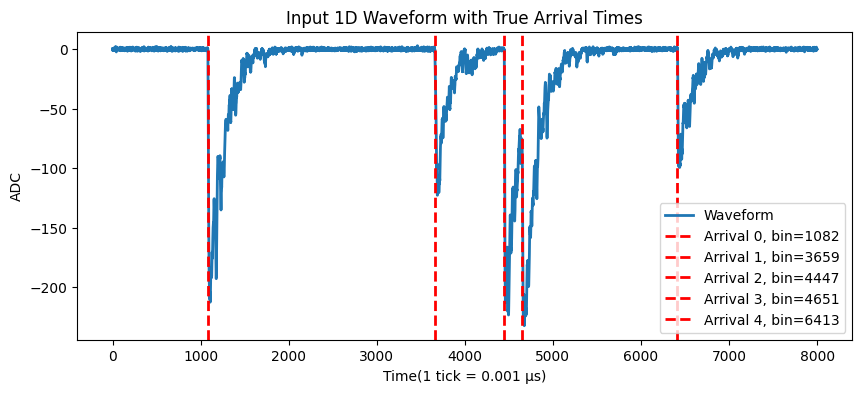

In [7]:
waveforms = np.load(PATH_TO_SAVE, allow_pickle=True).item()
waveform_id = 12

wf = waveforms['waveforms'][waveform_id]

ticks = np.arange(len(wf))
plt.figure(figsize=(10, 4))
plt.plot(ticks, wf, linewidth=2, label="Waveform")

t = waveforms['arrival_times'][waveform_id]
print("Arrival times:", t)

# Overlay arrival times as vertical dashed lines
for j, elem in enumerate(np.sort(t)):
    plt.axvline(
        x=elem,
        color="r",
        linestyle="--",
        linewidth=2,
        label=f"Arrival {j}, bin={int(elem)}"
    )

plt.xlabel(f"Time(1 tick = {sim.light_tick_size} µs)")
plt.ylabel("ADC")
plt.title("Input 1D Waveform with True Arrival Times")
plt.legend()
plt.show()

(8000,)


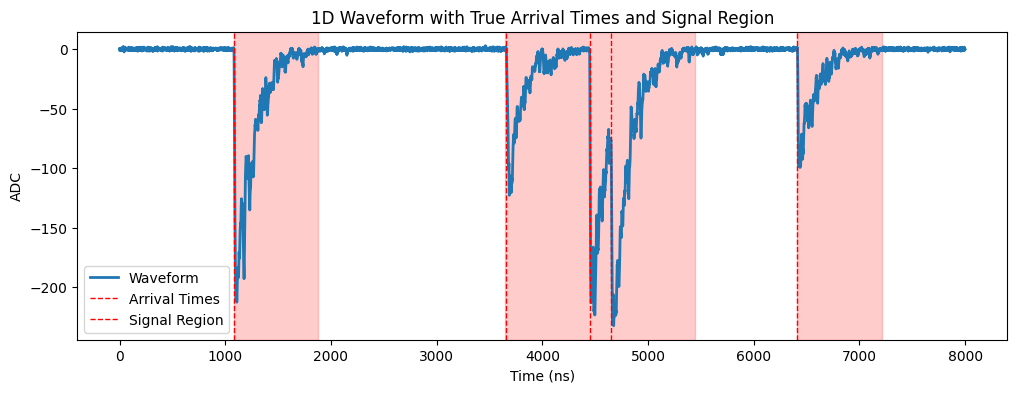

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import groupby
from operator import itemgetter

waveforms = np.load(PATH_TO_SAVE, allow_pickle=True).item()
waveform_id = 12

wf = waveforms['waveforms'][waveform_id]
ticks = np.arange(len(wf))

plt.figure(figsize=(12, 4))
plt.plot(ticks, wf, linewidth=2, label="Waveform")

# Plot arrival times as vertical dashed lines
t = waveforms['arrival_times'][waveform_id]
for elem in np.sort(t):
    plt.axvline(x=elem, color="r", linestyle="--", linewidth=1)

# Highlight signal regions based on labels
labels = per_wf_labels[waveform_id]  # shape [labels_per_waveform], 0/1
labels = np.repeat(labels, 10)
print(labels.shape)
signal_bins = np.where(labels == 1)[0]

# Group contiguous sequences in repeated array
for k, g in groupby(enumerate(signal_bins), lambda ix: ix[0] - ix[1]):
    group = list(map(itemgetter(1), g))
    plt.axvspan(group[0], group[-1], color='red', alpha=0.2)

plt.xlabel("Time (ns)")
plt.ylabel("ADC")
plt.title("1D Waveform with True Arrival Times and Signal Region")
plt.legend(["Waveform", "Arrival Times", "Signal Region"])
plt.show()